In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import xarray as xr

In [2]:
original_LES = xr.open_dataset(Path("data_original/spectra_LES.nc"))
original_Coh = xr.open_dataset(Path("data_original/spectra_coh_LES.nc"))

# Clean the coherence values

In [4]:
original_Coh.items()

ItemsView(<xarray.Dataset> Size: 13MB
Dimensions:             (radius: 1, height: 60, frequency: 3001,
                         spatialSeparation: 26, frequency_coh: 221)
Coordinates:
  * radius              (radius) float64 8B 0.9798
  * height              (height) float64 480B 1.974 6.413 11.34 ... 285.7 290.6
  * frequency           (frequency) float64 24kB 0.0 0.001667 ... 4.998 5.0
  * spatialSeparation   (spatialSeparation) float64 208B 0.0 11.11 ... 179.5
  * frequency_coh       (frequency_coh) float64 2kB 0.0 0.004539 ... 0.9986
Data variables:
    spectralDensity_u   (radius, height, frequency) float64 1MB 95.99 ... 0.0...
    spectralDensity_v   (radius, height, frequency) float64 1MB 103.9 ... 0.0...
    spectralDensity_w   (radius, height, frequency) float64 1MB 0.03981 ... 0...
    spectralDensity_uu  (radius, height, frequency) float64 1MB 2.215e+03 ......
    spectralDensity_vv  (radius, height, frequency) float64 1MB 534.9 ... 0.8316
    spectralDensity_ww  (radius, he

In [7]:
coh_spatial_separation = np.array(original_Coh["spatialSeparation"])
coh_frequency = np.array(original_Coh["frequency_coh"])
coh_u_alongCrosswind = np.array(original_Coh["coh_u_alongCross"])
coh_v_alongCrosswind = np.array(original_Coh["coh_v_alongCross"])
coh_w_alongCrosswind = np.array(original_Coh["coh_w_alongCross"])


In [13]:
print("Spatial separation size: ", len(coh_spatial_separation))
print("Frequency size: ", len(coh_frequency))
print("u along crosswind size: ", (coh_u_alongCrosswind).shape)
print("v along crosswind size: ", (coh_v_alongCrosswind).shape)
print("w along crosswind size: ", (coh_w_alongCrosswind).shape)


Spatial separation size:  26
Frequency size:  221
u along crosswind size:  (26, 221)
v along crosswind size:  (26, 221)
w along crosswind size:  (26, 221)


Ok, so the the coherence values are given over a 26 x 221 grid of spatial separation
values x frequency values. Notably, the frequency values are NOT the same as those
used in the calculation of 

In [15]:
print("Spatial separation min, max: ", np.min(coh_spatial_separation), np.max(coh_spatial_separation))
# Separation is in meters
print("Frequency min, max: ", np.min(coh_frequency), np.max(coh_frequency))
# Frequency is in Hz
print("u along crosswind min, max: ", np.min(coh_u_alongCrosswind), np.max(coh_u_alongCrosswind))
print("v along crosswind min, max: ", np.min(coh_v_alongCrosswind), np.max(coh_v_alongCrosswind))
print("w along crosswind min, max: ", np.min(coh_w_alongCrosswind), np.max(coh_w_alongCrosswind))


Spatial separation min, max:  0.0 179.50548672355896
Frequency min, max:  0.0 0.9986382206082614
u along crosswind min, max:  nan nan
v along crosswind min, max:  nan nan
w along crosswind min, max:  nan nan


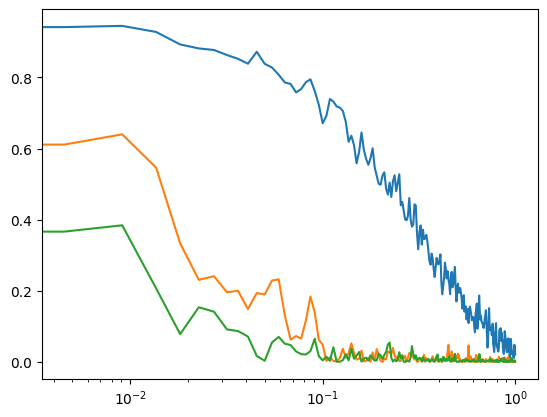

In [ ]:
# Plot the coherence data
plt.semilogx(coh_frequency, coh_u_alongCrosswind[2])
plt.semilogx(coh_frequency, coh_u_alongCrosswind[15])
plt.semilogx(coh_frequency, coh_u_alongCrosswind[25])

# Ok, so u coherence is NaN before the 2nd separation value

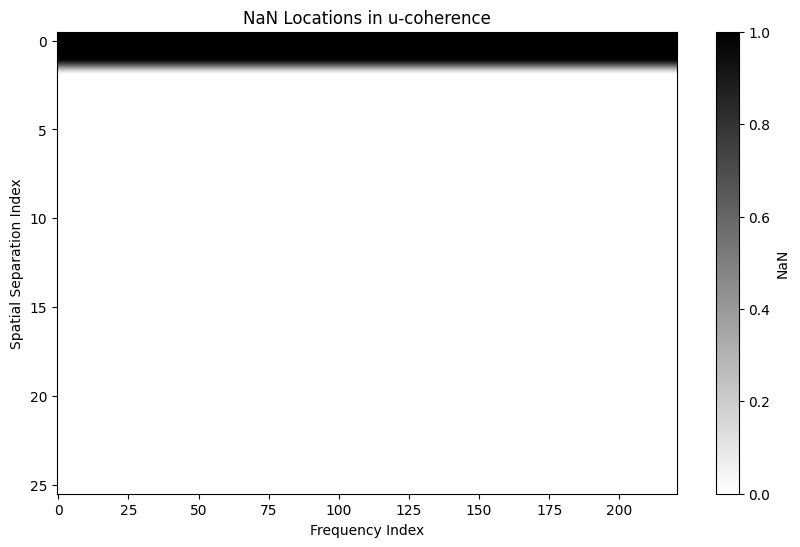

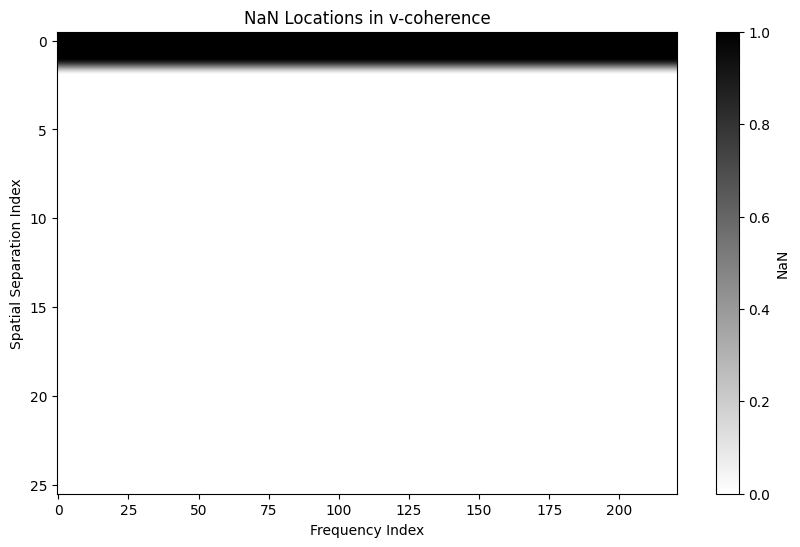

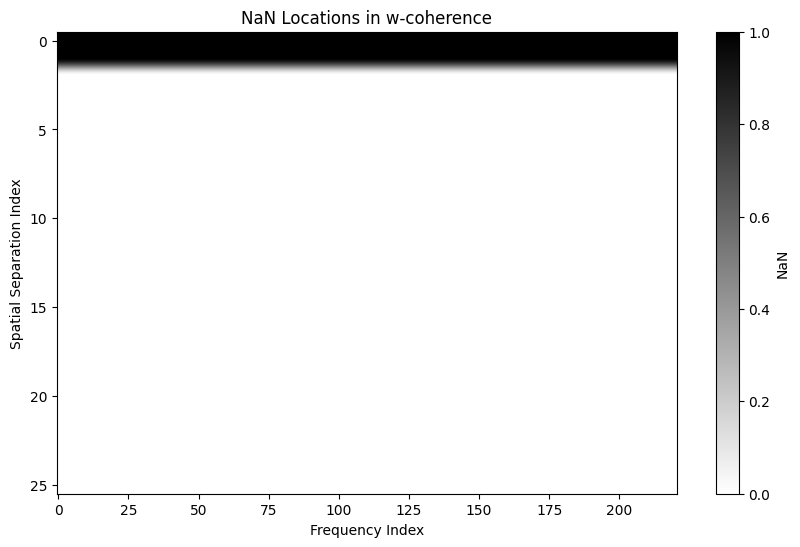


NaN Statistics:
u-coherence: 442 NaNs out of 5746 total points
v-coherence: 442 NaNs out of 5746 total points
w-coherence: 442 NaNs out of 5746 total points


In [18]:
# Function to plot nan locations in 2D arrays
def plot_nan_locations(data, title):
    plt.figure(figsize=(10, 6))
    plt.imshow(np.isnan(data), cmap='binary', aspect='auto')
    plt.colorbar(label='NaN')
    plt.title(f'NaN Locations in {title}')
    plt.xlabel('Frequency Index')
    plt.ylabel('Spatial Separation Index')
    plt.show()

# Plot NaN locations for each coherence component
plot_nan_locations(coh_u_alongCrosswind, 'u-coherence')
plot_nan_locations(coh_v_alongCrosswind, 'v-coherence')
plot_nan_locations(coh_w_alongCrosswind, 'w-coherence')

# Print summary statistics
print("\nNaN Statistics:")
print(f"u-coherence: {np.isnan(coh_u_alongCrosswind).sum()} NaNs out of {coh_u_alongCrosswind.size} total points")
print(f"v-coherence: {np.isnan(coh_v_alongCrosswind).sum()} NaNs out of {coh_v_alongCrosswind.size} total points")
print(f"w-coherence: {np.isnan(coh_w_alongCrosswind).sum()} NaNs out of {coh_w_alongCrosswind.size} total points")
